# TSFM Comparison Research — Progress & Next Steps

**As of:** 2026-08-24

**TL;DR:** Phase 1 (unified benchmark) is complete across all 4 models × 4 markets, with statistically-validated results. Infrastructure is reusable for any additional market. Phase 2 (regime characterization) has not started yet.


## 1. Environment & infrastructure setup

Four separate conda environments were required — the four repos have incompatible pinned dependencies (different `torch`/`numpy`/`gluonts` versions), so a shared environment wasn't viable:

| Env | Python | torch | Notes |
|---|---|---|---|
| `kronos` | 3.10 | 2.6.0+cu124 | |
| `lag-llama` | 3.10 | 2.6.0+cu124 | needed `setuptools<81` pinned (newer setuptools dropped `pkg_resources`, which `pytorch_lightning` still imports) |
| `timesfm` | 3.10 | 2.6.0+cu124 | uses the `src/` package (TimesFM 2.5), not the legacy `v1/` |
| `itransformer` | 3.10 | 2.0.0+cu118 | pinned per the repo's own `requirements.txt`, unlike the other three |

GPU: NVIDIA RTX 4060 Laptop (8GB VRAM) — CUDA confirmed working in all four environments.

**Project layout** (`D:\tsfmds`):
```
models/{Kronos,lag-llama,timesfm,iTransformer}   # cloned repos
data/raw/<market>_daily.csv                       # downloaded OHLCV data
data/eval_windows_<market>.csv                     # shared rolling-window definitions
data/results/<market>/                             # per-model results, summary, figures
scripts/                                           # eval harness (see §3)
notebooks/                                         # this notebook and its companion
```

Two machines are used for this project (Mac and this Windows PC); project files sync between them, but environment setup and Claude's own memory do not — both were re-established on this machine during this phase of work.


## 2. Data

Four daily OHLCV series pulled via `yfinance`, 2015-01-02 through 2026-08-21:

| Market | Ticker | Total rows | Train (≤ 2024-06-30) | Val (2024-07-01–2025-06-30) | Test (≥ 2025-07-01) |
|---|---|---|---|---|---|
| S&P 500 | `^GSPC` | 2,926 | 2,388 | 250 | 288 |
| Shanghai Composite (SSE) | `000001.SS` | 2,826 | 2,304 | 242 | 280 |
| Shenzhen Component (SZSE) | `399001.SZ` | 2,824 | 2,302 | 242 | 280 |
| Nikkei 225 | `^N225` | 2,843 | 2,320 | 244 | 279 |

**The train/val split boundary is fixed by date, not by percentage**, and is used differently by different models:
- **Kronos, Lag-Llama, TimesFM** are pretrained elsewhere and run **zero-shot** — the train/val rows are never used to update their weights, only as historical *context* at inference time (which is allowed to reach into train/val territory — that's just input, not a label the model could have memorized).
- **iTransformer** is the only model actually trained on this project's data: fit on train, early-stopped on val, evaluated on test.

The test period (2025-07-01 onward) was chosen specifically because it falls after Kronos's own published held-out window (ending ~2025-06-05) — the tightest of the three models' known pretraining cutoffs — so no model could have seen the evaluation targets during pretraining.


## 3. Pipeline validation (smoke tests)

Before any real evaluation, each model was run end-to-end once (checkpoint download → inference → plot) to confirm the pipeline actually worked, surfacing several non-obvious fixes along the way:

- Kronos: worked on the first real run once the environment was set up.
- Lag-Llama: needed (a) `setuptools<81` pinned, (b) a `torch.load` patch since PyTorch 2.6 defaults to `weights_only=True`, which rejects this checkpoint's embedded `gluonts` class object, (c) a synthetic uniform index for `gluonts.PandasDataset` since real trading-day calendars have weekend/holiday gaps it doesn't tolerate.
- TimesFM: worked on the first real run.
- iTransformer: no pretrained checkpoint exists — "proving it works" meant a real (short) training run, not just a forward pass.

These smoke tests used single, ad-hoc windows and are **not** the basis for any reported result — they were superseded by the rolling-window harness described next.


## 4. Phase 1 harness: design

A shared, reusable evaluation pipeline was built rather than one-off per-model scripts:

- **`scripts/common/windowing.py`** — generates the *same* rolling windows for every model on a given market: 400-day context, 20-day forecast horizon, 10-day stride, restricted so the forecast target always falls inside the leakage-safe test period (context may reach back into train/val — that's fine, it's historical input). This produces 26–27 windows per market.
- **`scripts/common/results_io.py`** — a shared long-format results schema (`model, window_id, target_date, step_ahead, actual_close, pred_close, pred_q10, pred_q90`) every model writes to, plus shared metric computation (MAE, RMSE, directional accuracy, 80%-interval coverage).
- **`scripts/eval_kronos.py` / `eval_lagllama.py` / `eval_timesfm.py` / `eval_itransformer.py`** — one script per model, each reading the shared windows and writing the shared results schema. Kronos needed a specific workaround: its own `predict()` averages away multiple stochastic samples internally, so genuine empirical quantiles are obtained by calling `predict()` repeatedly (10×) at `sample_count=1` and computing mean/q10/q90 ourselves.
- **`scripts/eval_itransformer.py`** required an additional custom dataset class (`Dataset_CustomDateSplit`) since iTransformer's own data loader only supports a fixed 70/10/20 split, not date-boundary splits — and a manual inverse-transform (its built-in `--inverse` flag has a shape-mismatch bug in multivariate-input/univariate-output mode).
- **`scripts/aggregate_results.py`** — combines all models' results and runs a **pairwise Diebold-Mariano test** (with a variance correction for the serial correlation from overlapping windows) so "model A beats model B" claims are statistically grounded, not just point-estimate differences.
- **`scripts/plot_phase1_summary.py`** / **`plot_cross_market_summary.py`** — produce the figures in §5/§6 below.

Every script above takes a `--dataset` argument, so adding a 5th market is: download → `windowing.py` → 4 eval scripts → `aggregate_results.py`, no new code.


## 5. Results by market

Each market: 4 models × 26–27 rolling windows × 20-day forecast horizon (400-day context), evaluated identically. Left panel of each figure: aggregate MAE / RMSE / directional accuracy / 80%-coverage. Right panel: one example window's forecasts overlaid against ground truth for all 4 models.


### SP500

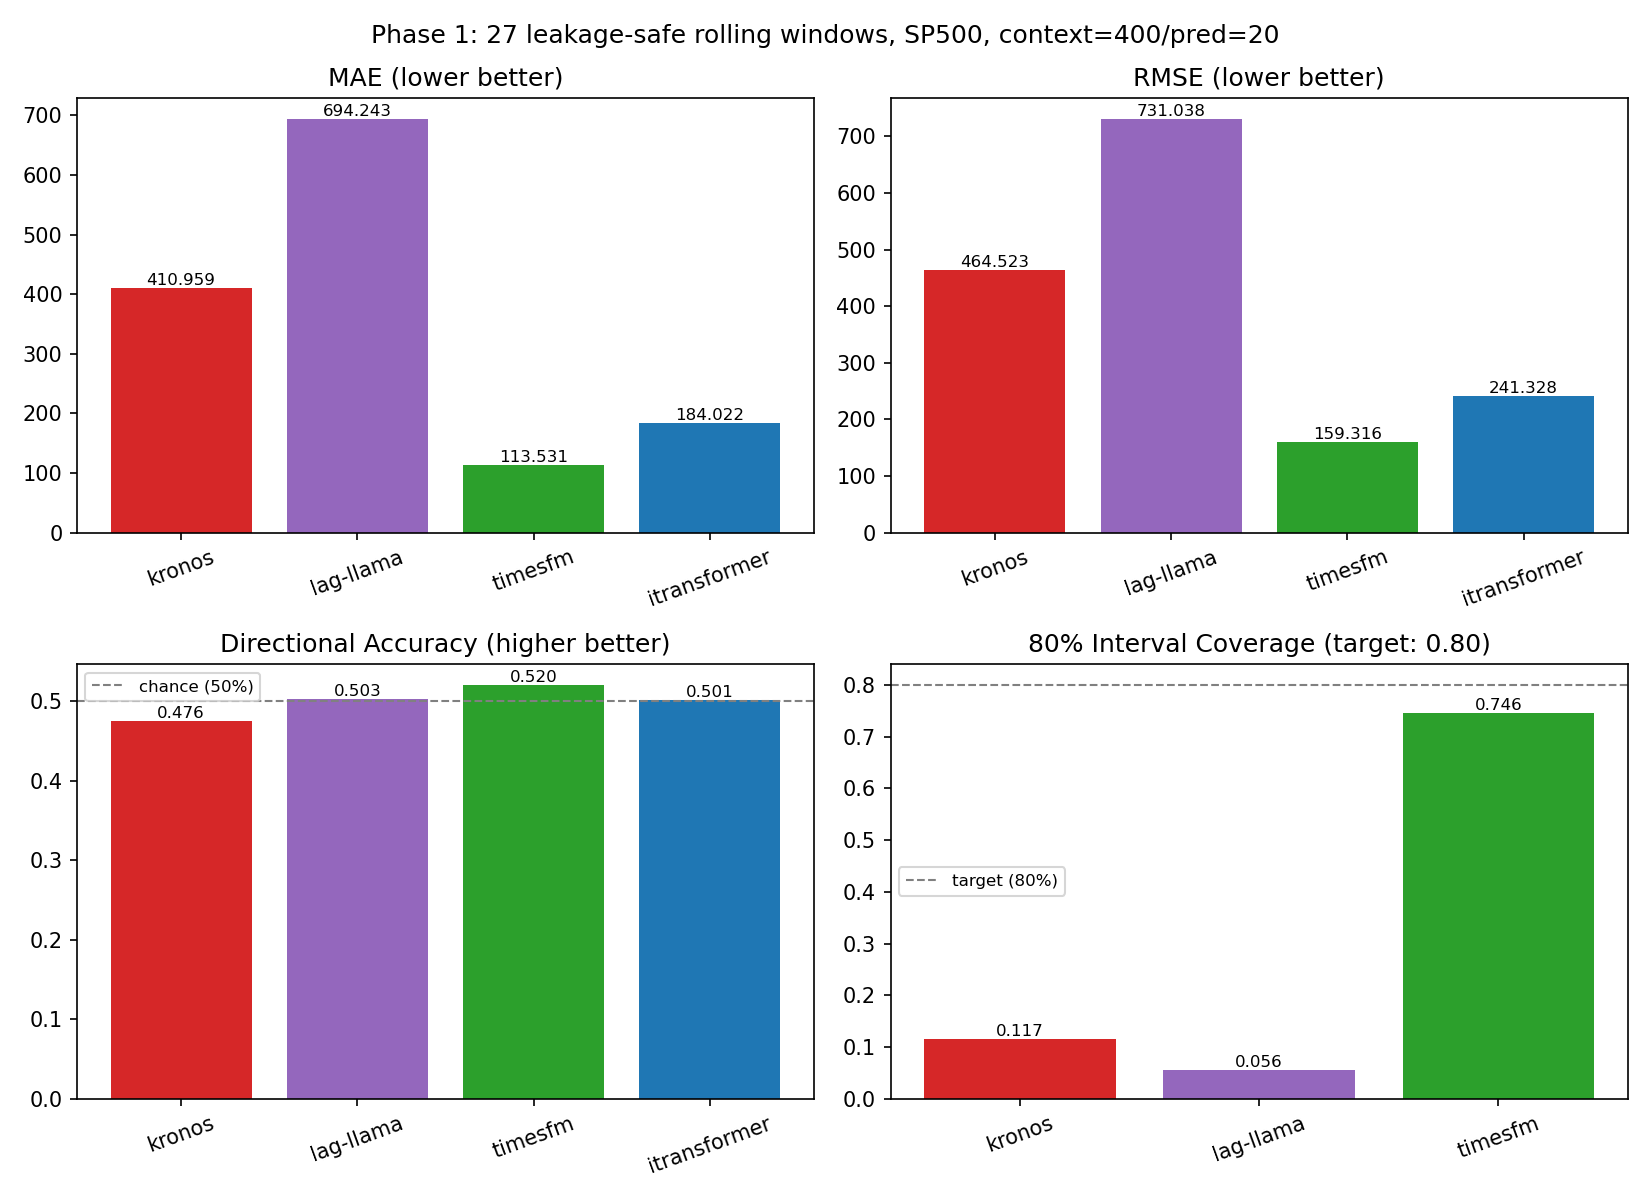


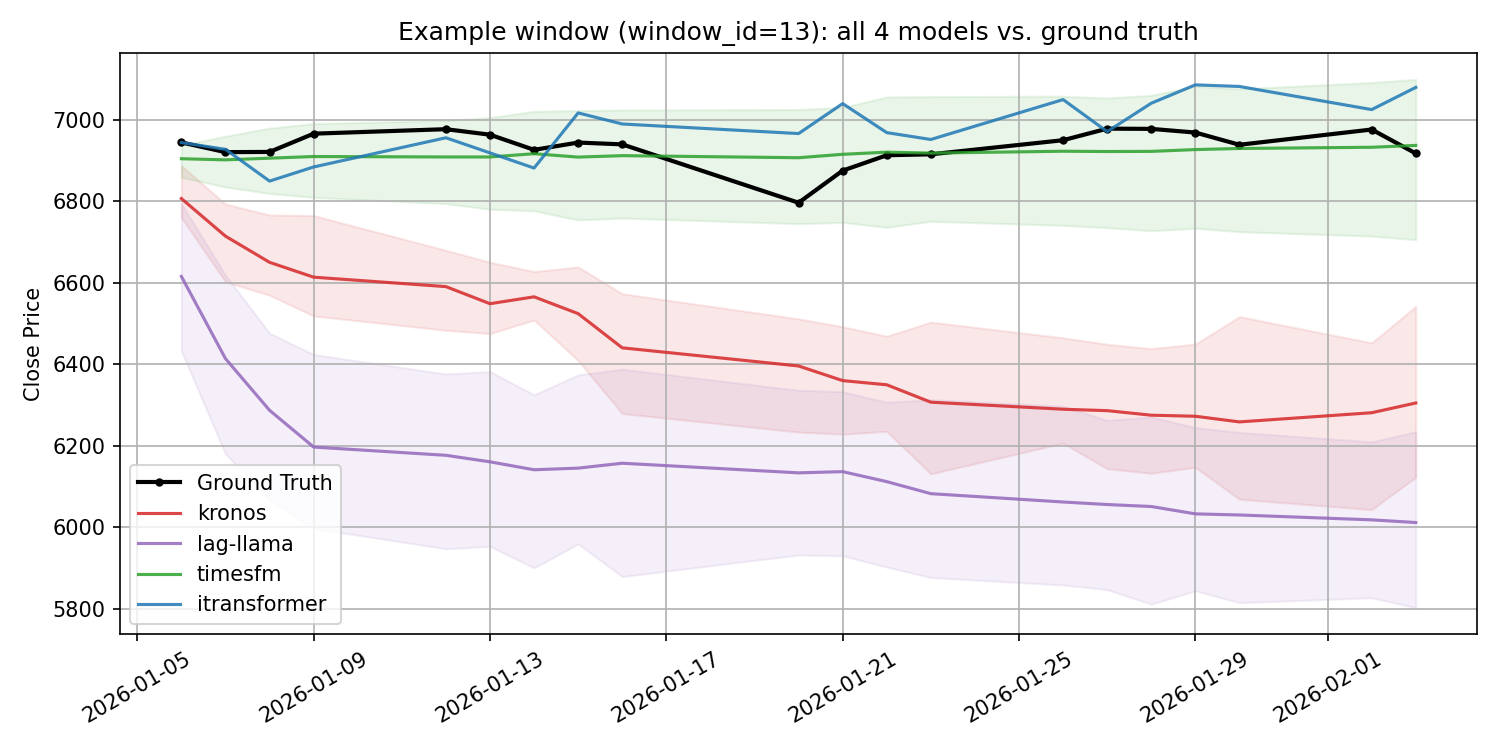

*S&P 500 — first market run; established TimesFM > iTransformer > Kronos > Lag-Llama, all pairwise differences significant (Diebold-Mariano, p<0.001).*


### SSE

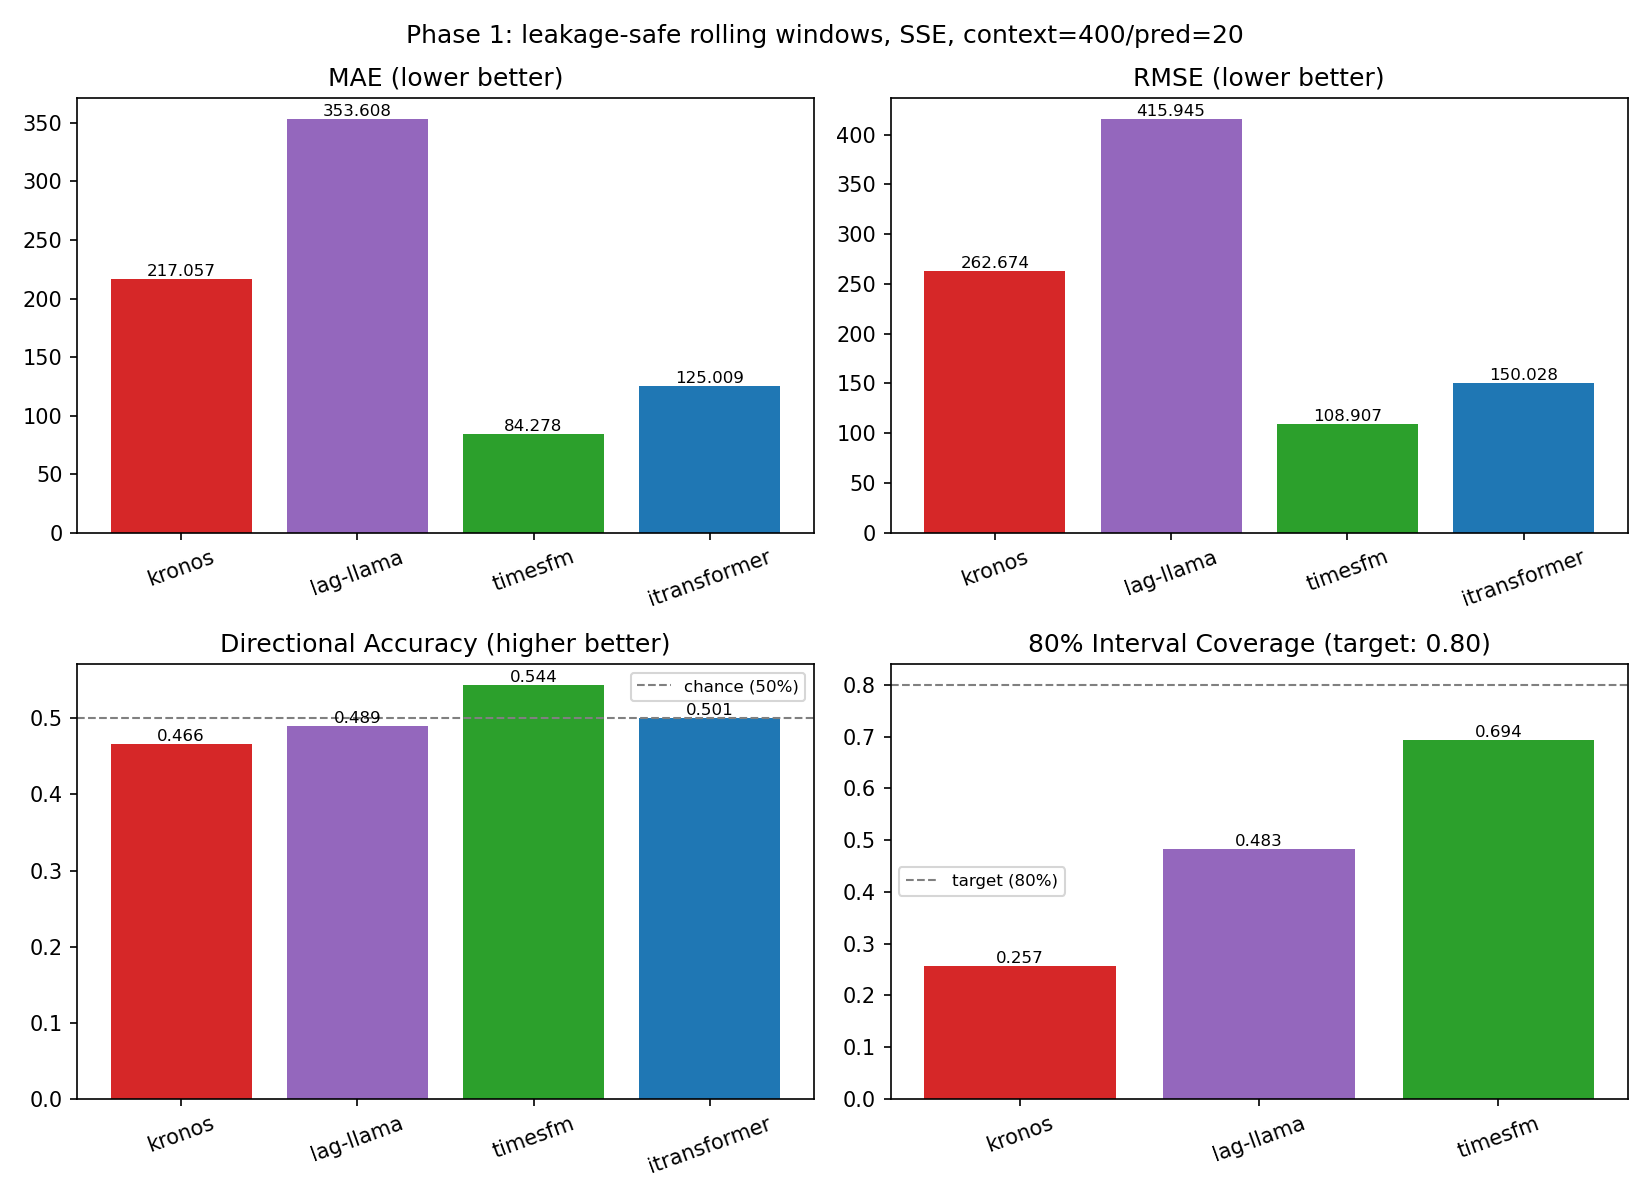


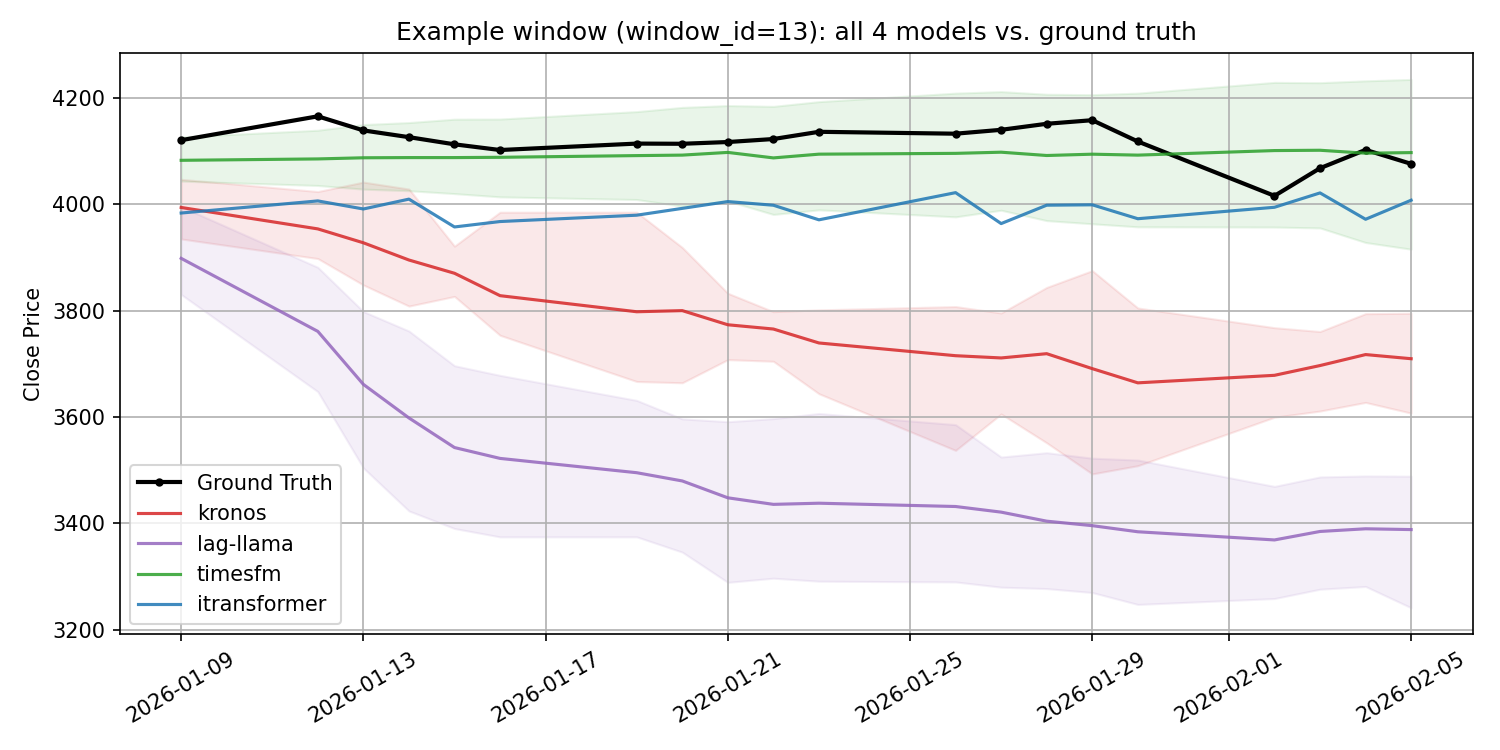

*Shanghai Composite — same ranking as SP500. Kronos's 80%-coverage improved to 25.7% here vs. 11.7% on SP500.*


### SZSE

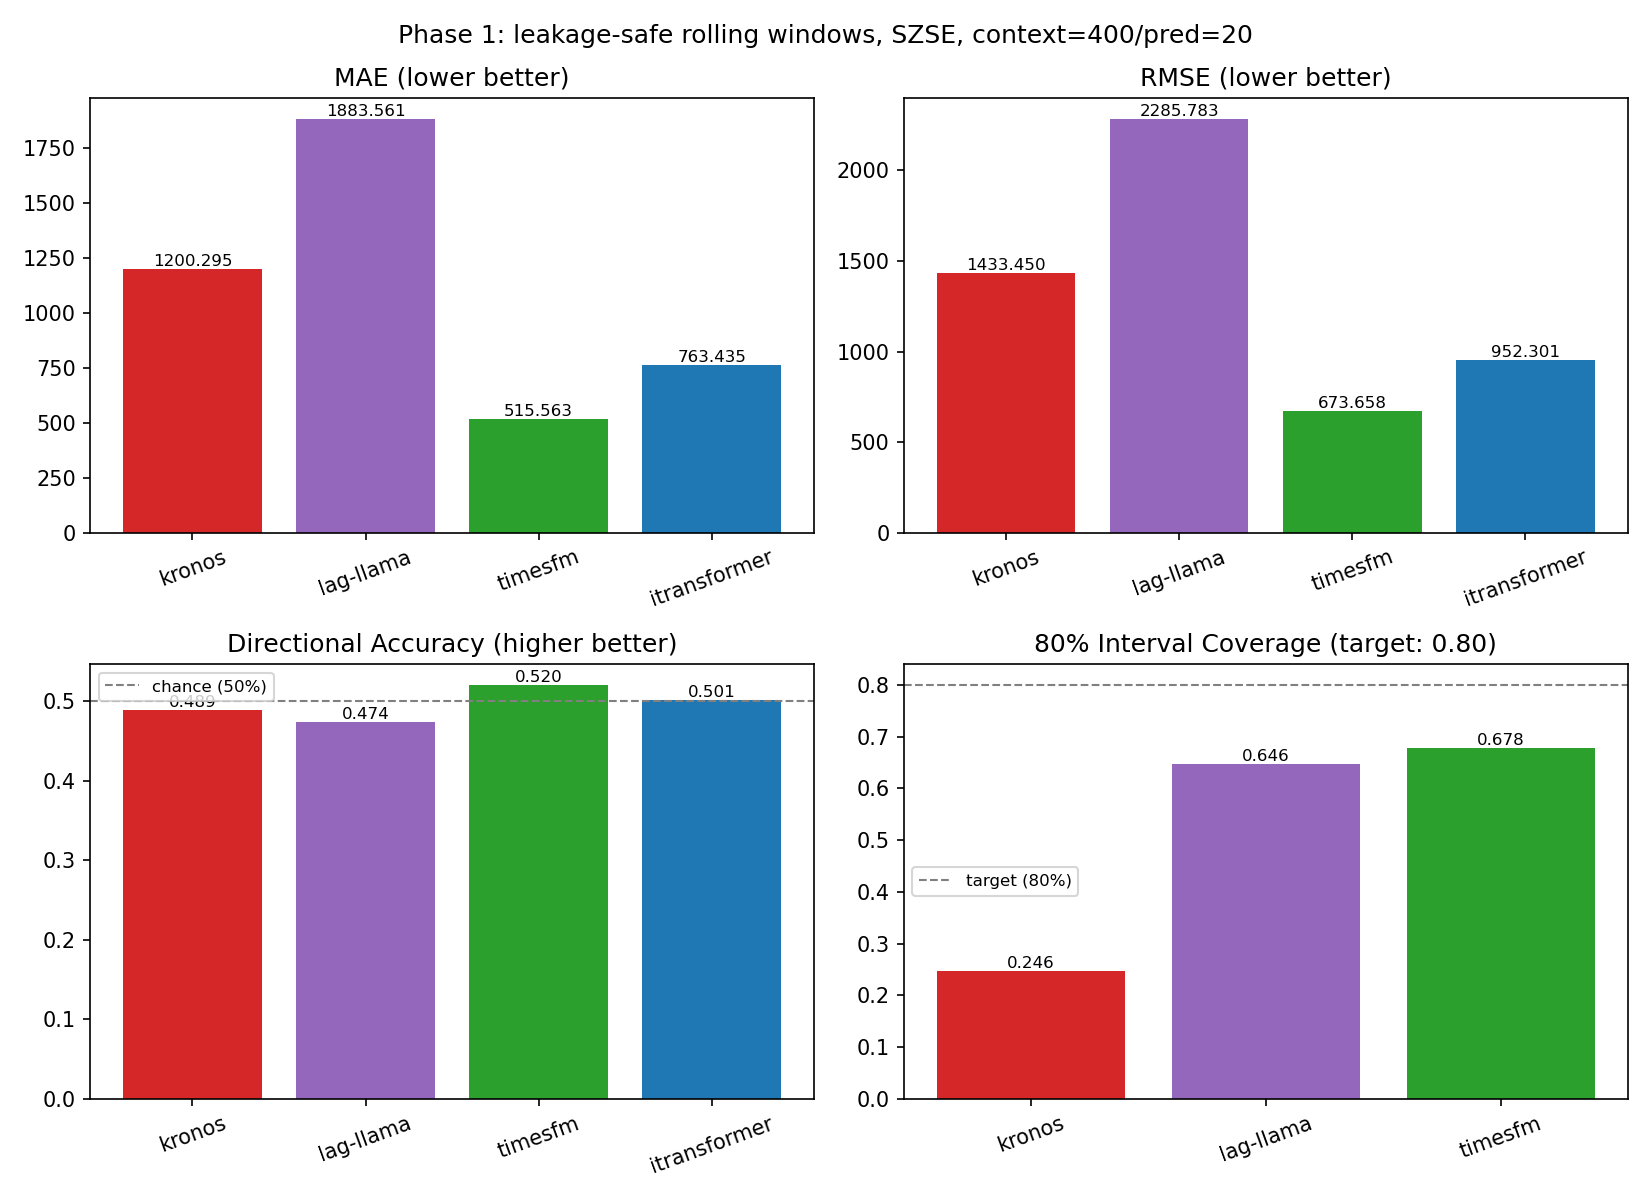


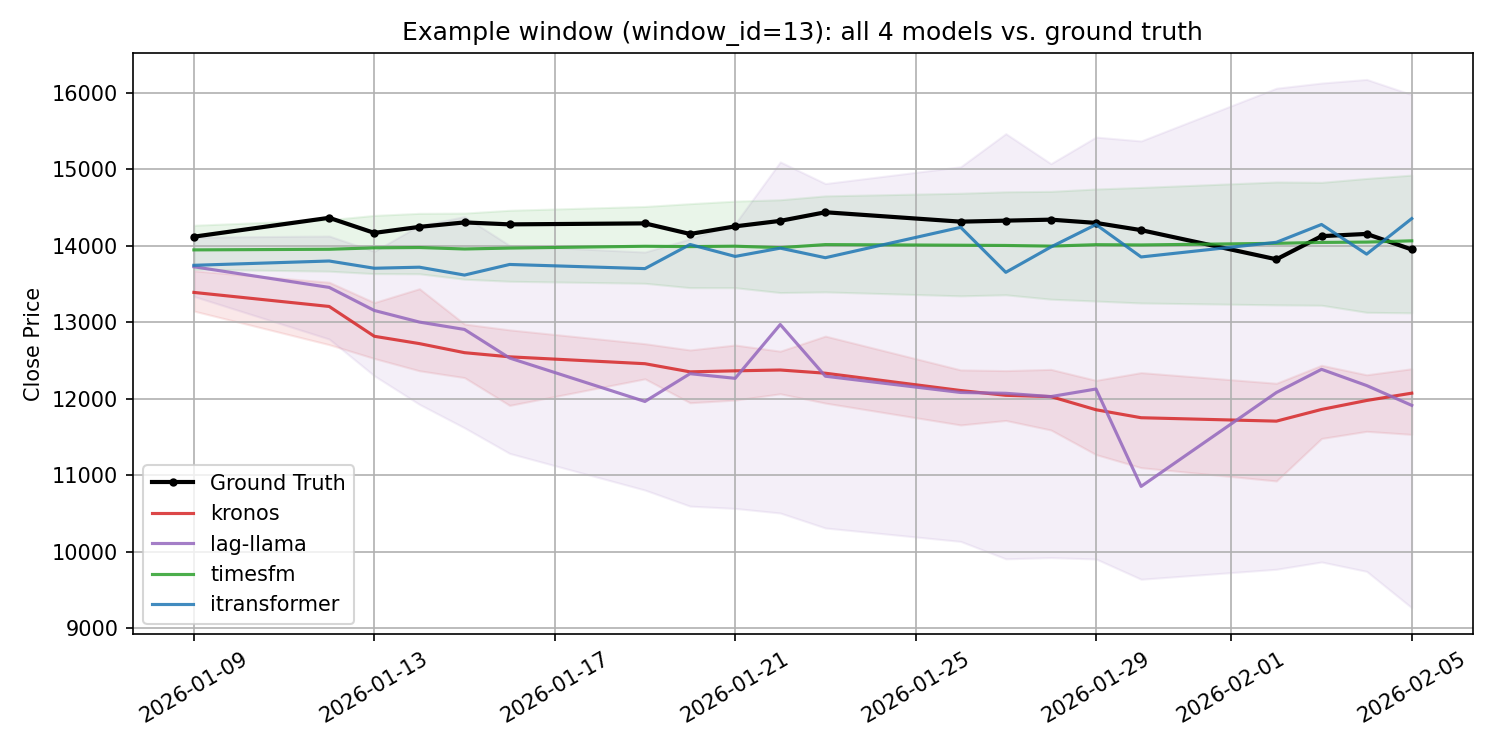

*Shenzhen Component — same ranking again. Kronos's coverage (24.6%) again notably better than on SP500.*


### Nikkei225

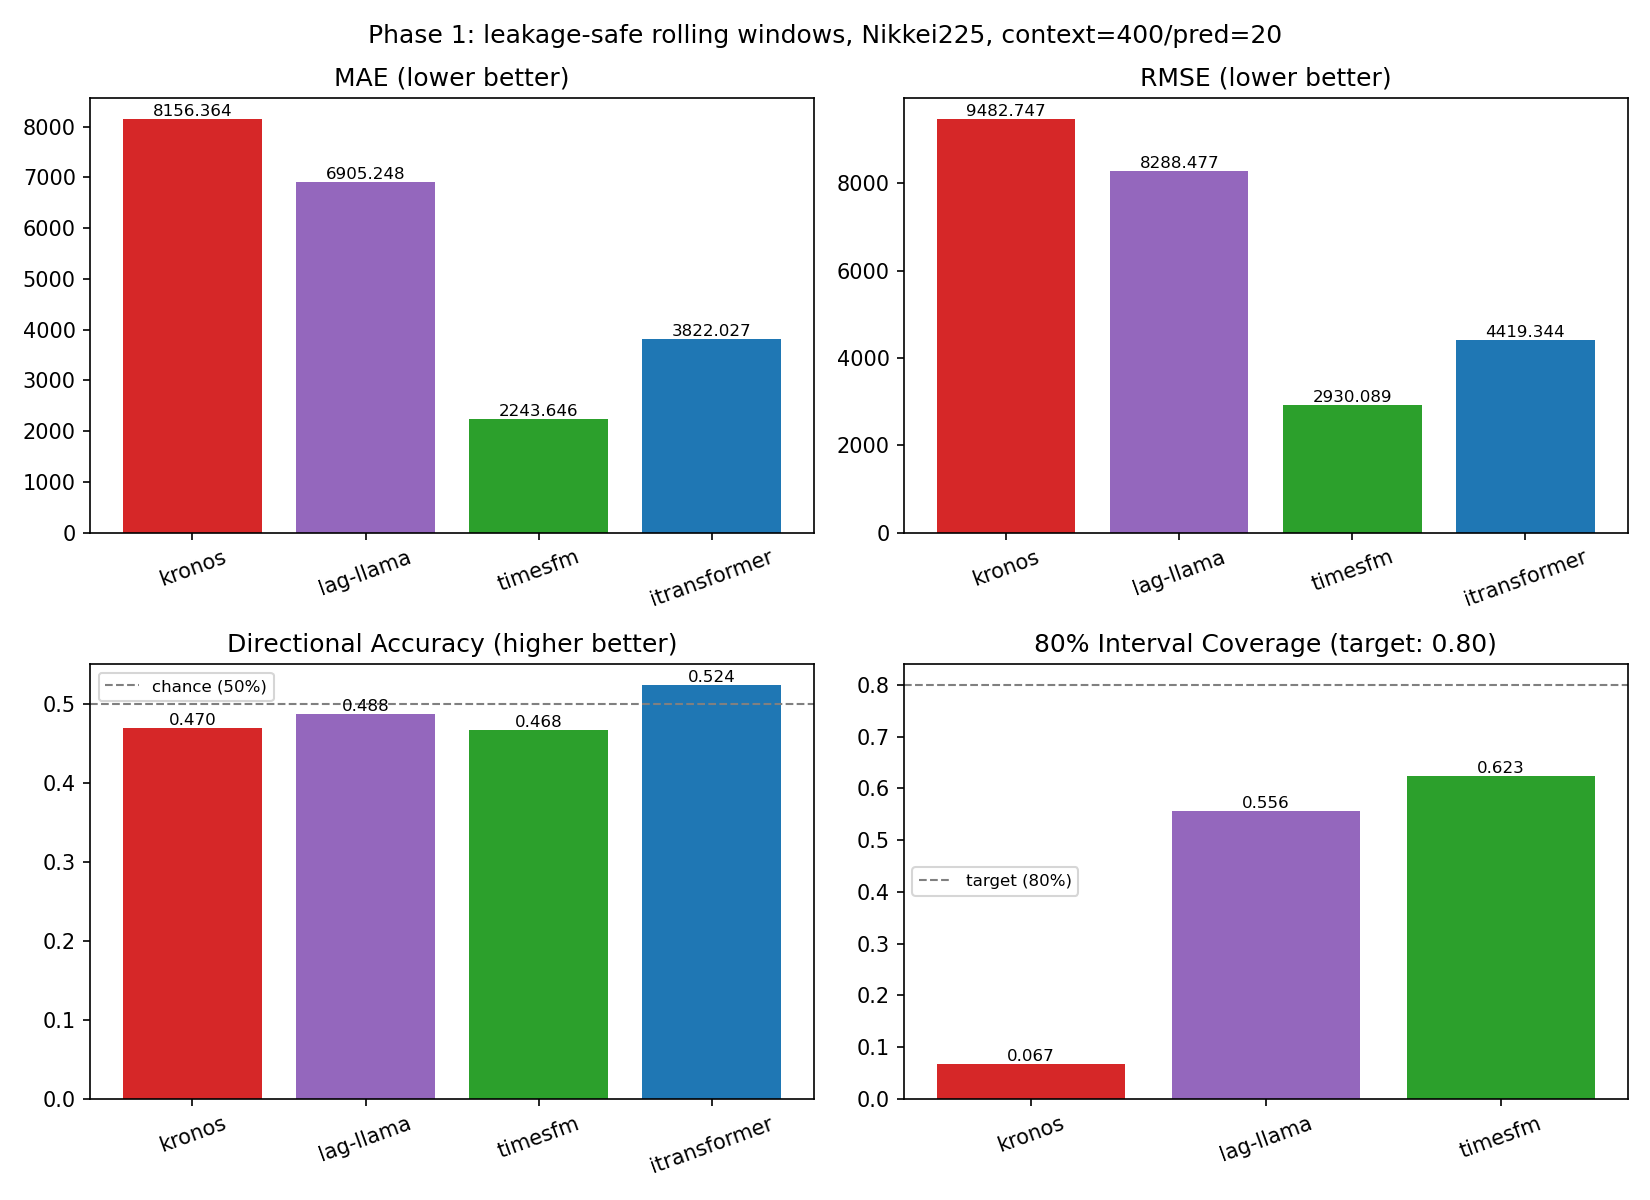


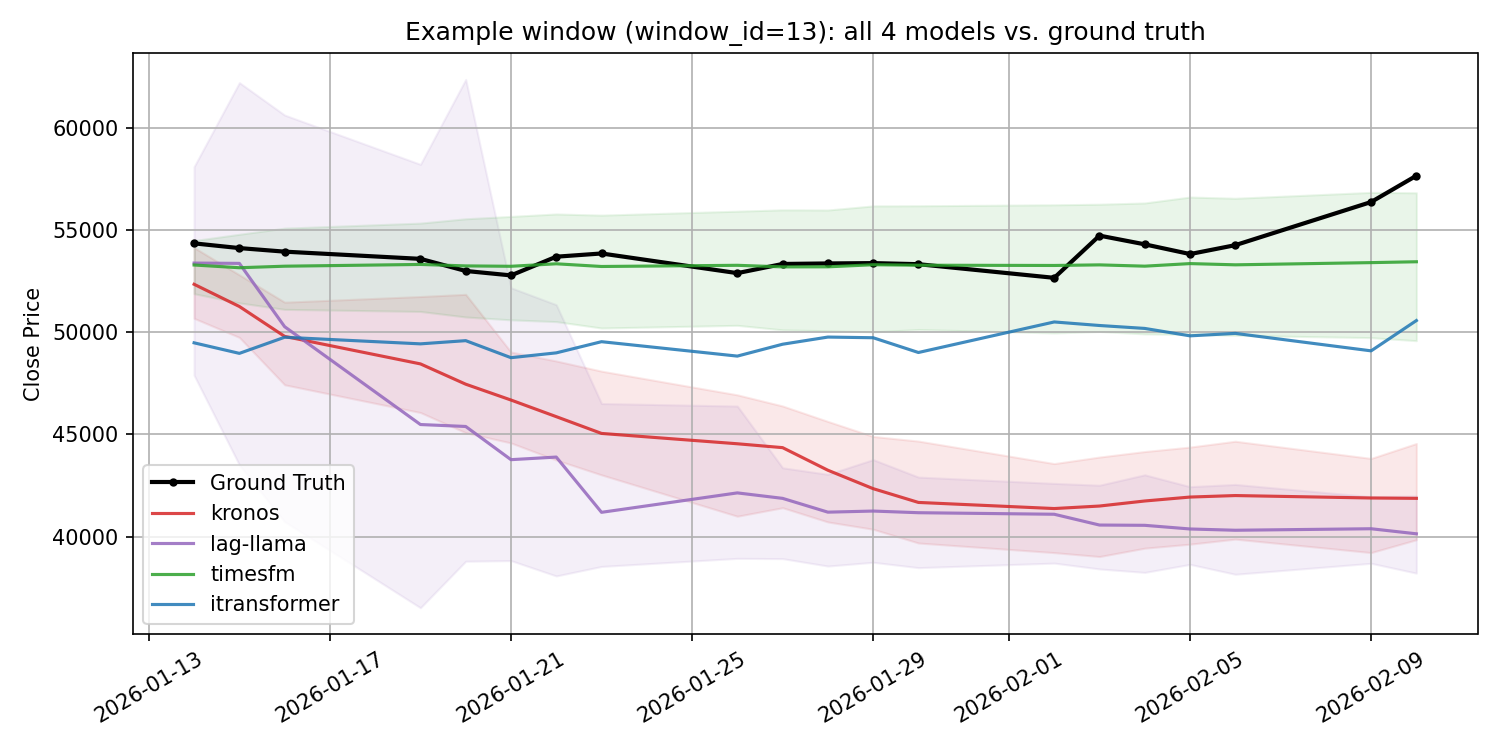

*Nikkei 225 — the ranking flips: Kronos becomes the *worst* model here, and is no longer significantly different from Lag-Llama (p=0.106), unlike every other market.*


## 6. Cross-market summary

Raw MAE isn't comparable across markets with very different price levels (SP500 ~7,000 vs. Nikkei225 ~40,000), so MAE is also reported as a percentage of each market's average close price ("relative MAE").


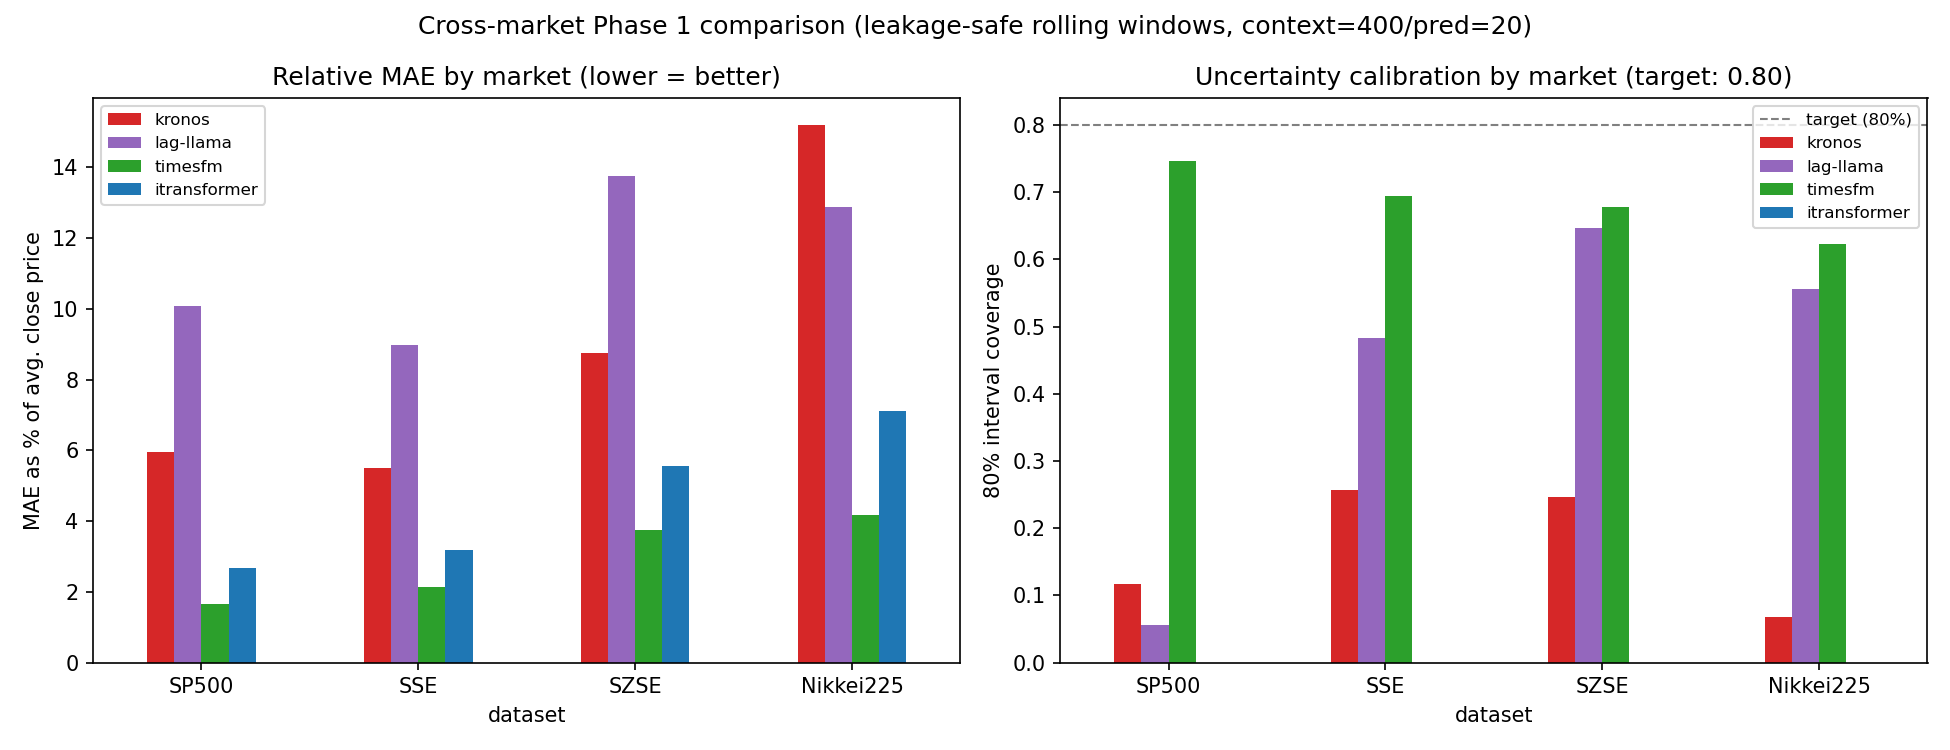


| Market | Kronos | Lag-Llama | TimesFM | iTransformer | Ranking (by MAE) |
|---|---|---|---|---|---|
| SP500 | 5.96% | 10.07% | **1.65%** | 2.67% | TimesFM > iTransformer > Kronos > Lag-Llama |
| SSE | 5.51% | 8.97% | **2.14%** | 3.17% | TimesFM > iTransformer > Kronos > Lag-Llama |
| SZSE | 8.76% | 13.74% | **3.76%** | 5.57% | TimesFM > iTransformer > Kronos > Lag-Llama |
| Nikkei225 | 15.20% | 12.87% | **4.18%** | 7.12% | TimesFM > iTransformer > **Lag-Llama > Kronos** |

*(MAE as % of each market's average close price; bold = best per market.)*


## 7. Key findings

1. **TimesFM wins on every market**, always by a statistically significant margin (Diebold-Mariano p<0.05, mostly p<0.001).
2. **Kronos's relative standing flips on Nikkei225.** It significantly beats Lag-Llama on SP500/SSE/SZSE, but becomes the *worst* model on Nikkei225 (worst MAE, worst 80%-coverage at 6.7%) and is no longer significantly different from Lag-Llama there (p=0.106). This is consistent with — though not conclusive proof of — a market-familiarity effect: Kronos's pretraining corpus reportedly emphasizes Chinese exchanges specifically, not Japanese ones. Timing leakage is controlled for (see §2); *market/asset familiarity* is a separate, less controllable effect worth flagging explicitly rather than assuming away.
3. **Calibration (80%-interval coverage) is market-dependent, not just model-dependent.** Lag-Llama's coverage swings from 5.6% (SP500, badly overconfident) to 48–65% (SSE/SZSE/Nikkei225, much closer to nominal). The *same model* is unreliable on one market and reasonably calibrated on others — uncertainty quality isn't a fixed model property.
4. **iTransformer (trained from scratch on ~2,300 rows per market) consistently ranks 2nd**, ahead of both zero-shot Kronos and Lag-Llama, on every market — but behind TimesFM. This is a legitimate result, not an embarrassment for the foundation models: it reflects the zero-shot-vs-supervised asymmetry noted in the plan (§4 of the plan notebook), and motivates eventually adding a fine-tuned-TSFM condition for a fully fair comparison.
5. **Directional accuracy is close to chance for all models on all markets** (47–54%, generally not significantly different from 50%), even where MAE/RMSE differ by 5–10×. Strong price-level accuracy does not imply a usable directional/trading signal — these are different skills and should be reported separately, not conflated.


## 8. Known limitations / caveats to carry forward

- **Zero-shot vs. fine-tuned asymmetry** (see plan §4): iTransformer is supervised on the target series, the three TSFMs are not. Current results should not be read as "TSFMs are more/less capable than conventional models" in general — only under these specific zero-shot conditions.
- **One asset per market.** Each of the 4 series is a single index; a finding here is one draw from a noisy process, not a proof about "the Chinese market" or "the US market" in general.
- **Overlapping windows.** 10-day stride with a 20-day horizon means adjacent windows share 10 days — forecast errors are not independent draws. This is handled in the Diebold-Mariano test via a Newey-West-style variance correction, but it's worth remembering when interpreting window counts as "27 independent tests".
- **Kronos market-familiarity vs. regime effects are currently confounded** — finding #2 above could partly reflect Phase 2 regime differences between markets rather than pretraining-corpus familiarity per se. Phase 2 should help disentangle this.


## 9. Next steps

**Immediate: Phase 2 — regime characterization**, per the original plan:
1. For each of the existing rolling windows (across all 4 markets), compute stationarity (ADF/KPSS or Hurst exponent), volatility (realized vol, optionally GARCH-implied), and trend strength (STL trend/remainder ratio or ADX) on the *context* portion of the window.
2. Bucket windows into regimes (e.g. stable / medium / unstable) using these characteristics.
3. Re-slice the Phase 1 results (already computed — no new model runs needed) by regime, and re-run Diebold-Mariano within each regime bucket to see whether model rankings change.
4. Specifically test whether finding #2 (Kronos's Nikkei225 flip) is better explained by regime differences between markets than by market-familiarity — or whether both effects are present and separable.

**Following Phase 2:** Phase 3 (uncertainty/calibration vs. regime — finding #3 above already motivates this) and Phase 4 (regime-aware dynamic fusion), per the original plan.
